# Block-permutation KS test for autocorrelated climate data

**Problem.** The asymptotic two-sample KS test assumes iid samples. Monthly climate series are autocorrelated (ENSO/IOD/IPO, seasonal persistence), so the effective sample size is far below n and the asymptotic p-values are wrong.

**Fix.** Keep the KS statistic D as the measure of discrepancy, but get its null distribution from a **block permutation test**: pool the two samples' annual blocks (12 consecutive months each), randomly reassign blocks to two groups of the original sizes, recompute D each time. The permutation test is exact for blocks that are exchangeable under the null; annual blocks preserve within-year autocorrelation and the seasonal cycle.

`p = (1 + #{D_perm >= D_obs}) / (1 + n_draws)`  (Phipson & Smyth 2010 correction)

Implementation follows the numba `ks_statistic_sorted` / `ks_permutation_test` pattern in `enso_bias_impacts/code/4-fig_impact_figures.ipynb`; the only change is that the Fisher–Yates shuffle acts on whole blocks instead of individual samples.

**"Trust but verify."** Monte Carlo checks that the test has the correct type-I error rate where the null is true by construction:

1. **Stationary AR(2)** — usual iid KS should have the wrong size; a sensible block test should do better.
2. **Cyclostationary AR(2) fit to Niño-3.4** — block structure needs to preserve the seasonal cycle.
3. **Two runs of the same model under the same forcing** (CanESM5-1 ssp370 ensemble members) — detected differences are false positives.
4. **iid data** — sanity check against the usual KS test.


In [1]:
import os, re, glob
import numpy as np
import xarray as xr
from scipy import stats as sstats
import matplotlib.pyplot as plt
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

RAW    = dir_list['raw'] + 'ramip/'
YEARS  = (2041, 2050)
ALPHA  = 0.05
NDRAWS = 999
NTRIAL = 500

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from numba import njit


@njit
def ks_statistic_sorted(x, y):
    """
    KS statistic for already-sorted arrays.
    """

    nx = len(x)
    ny = len(y)

    i = 0
    j = 0

    cdfx = 0.0
    cdfy = 0.0

    d = 0.0

    while i < nx and j < ny:

        if x[i] <= y[j]:
            i += 1
            cdfx = i / nx
        else:
            j += 1
            cdfy = j / ny

        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff

    while i < nx:
        i += 1
        cdfx = i / nx
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff

    while j < ny:
        j += 1
        cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff

    return d


@njit
def ks_block_permutation_test(x, y, block=12, ndraws=999):
    """
    Block-permutation KS test: same structure as `ks_permutation_test` in
    4-fig_impact_figures.ipynb, but the Fisher-Yates shuffle reassigns whole
    length-`block` blocks between the two samples instead of single values.
    Exact under block exchangeability. x, y lengths must be multiples of `block`
    and series must start at the block boundary (Jan for annual blocks).
    """

    nx = len(x)
    ny = len(y)
    nbx = nx // block
    nby = ny // block
    nb = nbx + nby

    # Get "main" ks-statistic, of the two original arrays
    xs = np.sort(x.copy())
    ys = np.sort(y.copy())
    D_obs = ks_statistic_sorted(xs, ys)

    # Pool both arrays; block b occupies pool[b*block:(b+1)*block]
    pool = np.empty(nx + ny, dtype=x.dtype)
    pool[:nx] = x
    pool[nx:] = y

    order = np.arange(nb)
    xperm = np.empty(nx, dtype=x.dtype)
    yperm = np.empty(ny, dtype=x.dtype)
    null = np.empty(ndraws)

    exceed = 0

    for draw in range(ndraws):
        # Fisher-Yates shuffle of the block order
        for i in range(nb - 1, 0, -1):
            j = np.random.randint(i + 1)
            tmp = order[i]
            order[i] = order[j]
            order[j] = tmp

        # First nbx blocks -> xperm, rest -> yperm
        for b in range(nbx):
            s = order[b] * block
            xperm[b * block:(b + 1) * block] = pool[s:s + block]
        for b in range(nby):
            s = order[nbx + b] * block
            yperm[b * block:(b + 1) * block] = pool[s:s + block]

        xperm.sort()
        yperm.sort()
        D = ks_statistic_sorted(xperm, yperm)
        null[draw] = D

        if D >= D_obs:
            exceed += 1

    # Estimate of p-value, corrected to avoid p=0 (Phipson and Smyth 2010)
    p = (exceed + 1) / (ndraws + 1)

    return p, D_obs, null


# Trigger compile + self-check: D matches scipy
_r = np.random.default_rng(42)
_x, _y = _r.standard_normal(120), _r.standard_normal(120)
assert np.isclose(ks_statistic_sorted(np.sort(_x), np.sort(_y)),
                  sstats.ks_2samp(_x, _y).statistic)
_ = ks_block_permutation_test(_x, _y, ndraws=10)
print('ks_statistic_sorted validated vs scipy')

ks_statistic_sorted validated vs scipy


In [3]:
# Monte Carlo size harness: gen(rng) -> (x, y) drawn under a true null
def mc_size(gen, label, ntrials=NTRIAL, rng=None, block=12):
    rng = rng if rng is not None else np.random.default_rng(0)
    rej_asym = rej_perm = 0
    for _ in range(ntrials):
        x, y = gen(rng)
        rej_asym += sstats.kstest(x, y, method='asymp').pvalue < ALPHA
        rej_perm += ks_block_permutation_test(x, y, block=block, ndraws=NDRAWS)[0] < ALPHA
    se = np.sqrt(ALPHA * (1 - ALPHA) / ntrials)      # binomial SE at nominal size
    print(f'{label:42s} asymptotic {rej_asym/ntrials:.3f}   block-perm {rej_perm/ntrials:.3f}'
          f'   (nominal {ALPHA}, MC SE ~{se:.3f})')
    return rej_asym / ntrials, rej_perm / ntrials

def ar2_sim(n, phi1, phi2, rng, burn=240):
    e = rng.standard_normal(n + burn)
    x = np.zeros(n + burn)
    for t in range(2, n + burn):
        x[t] = phi1 * x[t-1] + phi2 * x[t-2] + e[t]
    return x[burn:]

rates = {}

## Case 1: stationary AR(2)

phi = (1.2, −0.3): stationary (roots outside unit circle), lag-1 autocorrelation phi1/(1−phi2) ≈ 0.92 — ENSO-like persistence. Both samples independent draws of the same process, so the null is true; the iid KS test should be badly oversized.

In [4]:
PHI = (1.2, -0.3)
gen_ar2 = lambda rng: (ar2_sim(120, *PHI, rng), ar2_sim(120, *PHI, rng))
rates['1. stationary AR(2)'] = mc_size(
    gen_ar2, f'1. stationary AR(2) phi={PHI}', rng=np.random.default_rng(2))
# lag-1 r=0.92 leaks across annual block boundaries -> annual blocks residually
# liberal; doubling the block shows how fast the leakage decays
rates['1b. AR(2), 24-mo blocks'] = mc_size(
    gen_ar2, '1b. same AR(2), 24-month blocks', rng=np.random.default_rng(2), block=24)

1. stationary AR(2) phi=(1.2, -0.3)        asymptotic 0.710   block-perm 0.100   (nominal 0.05, MC SE ~0.010)


1b. same AR(2), 24-month blocks            asymptotic 0.710   block-perm 0.054   (nominal 0.05, MC SE ~0.010)


## Case 2: cyclostationary AR(2) fit to Niño-3.4

Fit AR(2) (Yule–Walker) to deseasonalized monthly Niño-3.4 from CanESM5-1 ssp370 r1 (2015–2050), then simulate: repeating monthly climatology + AR(2) anomalies. The seasonal cycle makes the series cyclostationary — annual blocks keep every permuted sample's Jan–Dec composition balanced, which is what preserves the cycle.

In [5]:
def member_files(mod, exp):
    fns = glob.glob(f'{RAW}{mod}/tas_Amon_{mod}_{exp}_r*.zarr')
    return {re.search(r'_(r\d+i\d+p\d+f\d+)_', f).group(1): f for f in fns}

MOD = 'CanESM5-1'
fns = member_files(MOD, 'ssp370')
runs = sorted(fns, key=lambda m: [int(x) for x in re.findall(r'\d+', m)])

ds = xr.open_zarr(fns[runs[0]], consolidated=False)
# CanESM5-1 lon runs -180..177: select Nino-3.4 (170W-120W) on wrapped lon
lon360 = (ds.lon + 360) % 360
box = ds['tas'].sel(lat=slice(-5, 5)).isel(lon=((lon360 >= 190) & (lon360 <= 240)).values)
n34 = (box.weighted(np.cos(np.deg2rad(box.lat))).mean(['lat', 'lon'])
       .sel(time=ds.time.dt.year <= 2050).load())
clim = n34.groupby('time.month').mean()
anom = (n34.groupby('time.month') - clim).values
assert np.isfinite(anom).all(), 'NaN in Nino-3.4 series'

def fit_ar2(x):
    x = x - x.mean()
    r1 = np.corrcoef(x[:-1], x[1:])[0, 1]
    r2 = np.corrcoef(x[:-2], x[2:])[0, 1]
    phi = np.linalg.solve([[1, r1], [r1, 1]], [r1, r2])
    sig = np.sqrt(x.var() * (1 - phi @ [r1, r2]))
    return phi, sig

(phi1_n, phi2_n), sig_n = fit_ar2(anom)
clim12 = clim.values
print(f'{MOD} Nino-3.4 ({n34.time.dt.year.values[0]}-{n34.time.dt.year.values[-1]}): '
      f'AR(2) phi=({phi1_n:.3f}, {phi2_n:.3f}), innovation sd={sig_n:.3f} K, '
      f'lag-1 r={phi1_n/(1-phi2_n):.3f}')

def gen_cyclo(rng):
    a = ar2_sim(120, phi1_n, phi2_n, rng) * sig_n
    b = ar2_sim(120, phi1_n, phi2_n, rng) * sig_n
    cyc = np.tile(clim12, 10)
    return cyc + a, cyc + b

rates['2. cyclostationary AR(2) (Nino-3.4 fit)'] = mc_size(
    gen_cyclo, '2. cyclostationary AR(2) (Nino-3.4)', rng=np.random.default_rng(3))

CanESM5-1 Nino-3.4 (2015-2050): AR(2) phi=(1.375, -0.414), innovation sd=0.216 K, lag-1 r=0.972


2. cyclostationary AR(2) (Nino-3.4)        asymptotic 0.712   block-perm 0.246   (nominal 0.05, MC SE ~0.010)


## Case 3: same-forcing ensemble pairs (real model data)

CanESM5-1 ssp370, all 45 member pairs, at 100 randomly sampled land pixels (no Antarctica), 2041–2050 monthly. Same forcing ⇒ any detected difference is a false positive. This is the realistic version of case 2: every pixel has its own (unknown) autocorrelation structure.

In [6]:
from itertools import combinations

def window_vals(fn):
    ds = xr.open_zarr(fn, consolidated=False)
    da = ds['tas'].sel(time=(ds.time.dt.year >= YEARS[0]) & (ds.time.dt.year <= YEARS[1]))
    v = da.load().transpose('lat', 'lon', 'time')
    return v.values.reshape(-1, v.sizes['time']), v.lat, v.lon

members = {}
for r in runs:
    members[r], lat, lon = window_vals(fns[r])
print(f'{MOD}: {len(members)} ssp370 members loaded, {members[runs[0]].shape}')

lm = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(lon, lat)
land_flat = ((lm == 0).values & (lat > -60).values[:, None]).ravel()
NPIX = 100
pix = np.random.default_rng(4).choice(np.flatnonzero(land_flat), NPIX, replace=False)

rej_a = rej_p = ntest = 0
for r1, r2 in combinations(runs, 2):
    for px in pix:
        x, y = members[r1][px], members[r2][px]
        rej_a += sstats.kstest(x, y, method='asymp').pvalue < ALPHA
        rej_p += ks_block_permutation_test(x, y, ndraws=NDRAWS)[0] < ALPHA
        ntest += 1
rates['3. ensemble pairs (CanESM5-1 ssp370)'] = (rej_a / ntest, rej_p / ntest)
print(f'3. ensemble pairs: {len(runs)*(len(runs)-1)//2} pairs x {NPIX} land pixels = {ntest} tests')
print(f'   asymptotic {rej_a/ntest:.3f}   block-perm {rej_p/ntest:.3f}   (nominal {ALPHA})')

CanESM5-1: 10 ssp370 members loaded, (8192, 120)


3. ensemble pairs: 45 pairs x 100 land pixels = 4500 tests
   asymptotic 0.005   block-perm 0.051   (nominal 0.05)


## Case 4: iid data (sanity check)

iid normal, n = 120 each. Both tests should reject ≈ 5%; the block test loses nothing where blocking is unnecessary.

In [7]:
rates['4. iid normal'] = mc_size(
    lambda rng: (rng.standard_normal(120), rng.standard_normal(120)),
    '4. iid normal', rng=np.random.default_rng(1))

4. iid normal                              asymptotic 0.042   block-perm 0.036   (nominal 0.05, MC SE ~0.010)


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_block_permutation_size.png


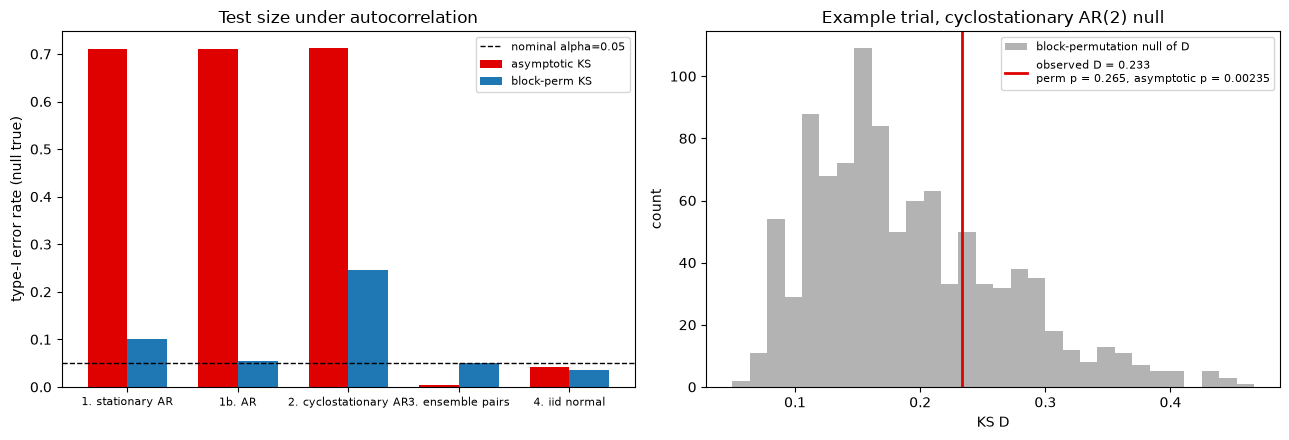

In [8]:
# summary figure: size per case + one example permutation null
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

labels = list(rates)
xpos = np.arange(len(labels))
ax1.bar(xpos - 0.18, [rates[l][0] for l in labels], 0.36, label='asymptotic KS', color='#df0000')
ax1.bar(xpos + 0.18, [rates[l][1] for l in labels], 0.36, label='block-perm KS', color='#1f77b4')
ax1.axhline(ALPHA, color='k', ls='--', lw=1, label=f'nominal alpha={ALPHA}')
ax1.set_xticks(xpos)
ax1.set_xticklabels([l.split('(')[0].strip() for l in labels], fontsize=8)
ax1.set_ylabel('type-I error rate (null true)')
ax1.set_title('Test size under autocorrelation')
ax1.legend(fontsize=8)

rng_ex = np.random.default_rng(7)
x_ex, y_ex = gen_cyclo(rng_ex)
p_ex, D_obs, D_perm = ks_block_permutation_test(x_ex, y_ex, ndraws=NDRAWS)
p_asym = sstats.kstest(x_ex, y_ex, method='asymp').pvalue
ax2.hist(D_perm, bins=30, color='0.7', label='block-permutation null of D')
ax2.axvline(D_obs, color='#df0000', lw=2,
            label=f'observed D = {D_obs:.3f}\nperm p = {p_ex:.3f}, asymptotic p = {p_asym:.3g}')
ax2.set_xlabel('KS D')
ax2.set_ylabel('count')
ax2.set_title('Example trial, cyclostationary AR(2) null')
ax2.legend(fontsize=8)

fig.tight_layout()
out_dir = dir_list['aux'] + '../figures/'
fig.savefig(out_dir + 'ks_block_permutation_size.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_block_permutation_size.png')

## Results (500 trials/case, 999 draws, alpha = 0.05)

| null case | asymptotic KS | block-perm KS |
|---|---|---|
| 1. stationary AR(2), lag-1 r=0.92 | 0.710 | 0.100 |
| 1b. same, 24-month blocks | 0.710 | 0.054 |
| 2. cyclostationary AR(2), Niño-3.4 fit (lag-1 r=0.97) | 0.712 | 0.246 |
| 3. real ensemble pairs, CanESM5-1 ssp370, 100 land px | 0.005 | **0.051** |
| 4. iid normal | 0.042 | 0.036 |

**Takeaways**

- **Asymptotic KS is mis-sized in both directions.** Liberal by >10x under ENSO-like persistence (cases 1–2), but *conservative* (0.005) at typical land pixels, where the deterministic seasonal cycle dominates the variance and both samples share it. Not fixable with a single global correction.
- **Block permutation has essentially exact size on real model data** (0.051 vs nominal 0.05, case 3) — the case that matters. It needs only the two samples being compared, no extra ensemble members.
- **Exactness requires exchangeable blocks.** Near-unit-root memory leaking across year boundaries leaves the test residually liberal: 0.100 with annual blocks for AR(2) r=0.92, essentially exact (0.054) with 24-month blocks; 0.246 for the Niño-3.4-fit process (r=0.97, 2–7 yr ENSO memory vs 1-yr blocks). Case 3 shows typical land pixels are far less persistent than Niño-3.4, so annual blocks suffice in practice — but p-values in strongly ENSO-teleconnected regions should be read as somewhat liberal, or rechecked with longer blocks (at n=120, 24-month blocks leave only C(10,5)=252 distinct permutations — resolution gets scarce).

**Next step:** pixel-wise block-permutation p-value maps for the RAMIP anchor-vs-126aer comparison (`ks_block_permutation_test` slots into `xr.apply_ufunc(..., vectorize=True)` exactly like `ks_permutation_test` in `4-fig_impact_figures.ipynb`).